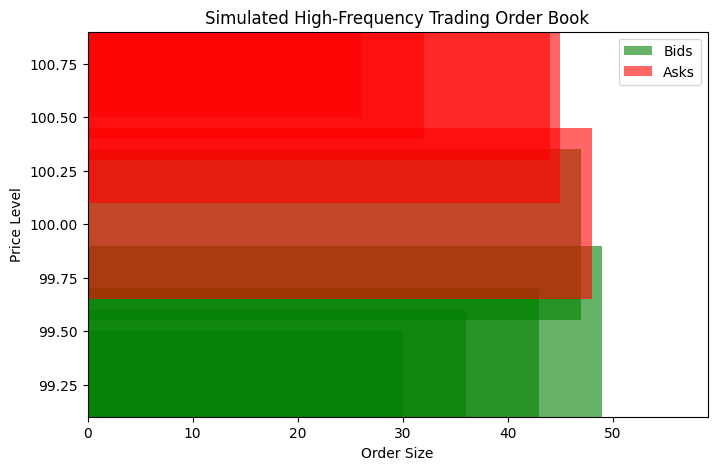

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Initialize order book depth
order_book = {
    'bid_prices': [99.5, 99.4, 99.3, 99.2, 99.1],
    'bid_sizes': [50, 45, 40, 35, 30],
    'ask_prices': [100.5, 100.6, 100.7, 100.8, 100.9],
    'ask_sizes': [50, 45, 40, 35, 30]
}

# Simulate order book updates
def update_order_book():
    """Simulate order book updates with HFT activity."""
    spread = order_book['ask_prices'][0] - order_book['bid_prices'][0]
    if spread > 0.1:
        # Simulate HFT narrowing the spread
        mid_price = (order_book['bid_prices'][0] + order_book['ask_prices'][0]) / 2
        order_book['bid_prices'][0] = round(mid_price - 0.05, 2)
        order_book['ask_prices'][0] = round(mid_price + 0.05, 2)

    # Randomly change bid/ask sizes
    order_book['bid_sizes'] = [max(5, s + random.randint(-5, 5)) for s in order_book['bid_sizes']]
    order_book['ask_sizes'] = [max(5, s + random.randint(-5, 5)) for s in order_book['ask_sizes']]

    # Slightly shift prices randomly to simulate market movements
    order_book['bid_prices'] = [round(p + random.choice([-0.1, 0, 0.1]), 2) for p in order_book['bid_prices']]
    order_book['ask_prices'] = [round(p + random.choice([-0.1, 0, 0.1]), 2) for p in order_book['ask_prices']]

# Update order book before visualization
update_order_book()

# Create static order book visualization
plt.figure(figsize=(8, 5))

# Plot bid side
plt.barh(order_book['bid_prices'], order_book['bid_sizes'], color='green', label='Bids', alpha=0.6)

# Plot ask side
plt.barh(order_book['ask_prices'], order_book['ask_sizes'], color='red', label='Asks', alpha=0.6)

plt.xlabel('Order Size')
plt.ylabel('Price Level')
plt.title('Simulated High-Frequency Trading Order Book')
plt.legend()
plt.xlim(0, max(order_book['bid_sizes'] + order_book['ask_sizes']) + 10)
plt.ylim(min(order_book['bid_prices']), max(order_book['ask_prices']))

# Show the static visualization
plt.show()
